In [ ]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)
np.random.seed(42)

#Cell 2 —Mock Simulators (placeholder for Member B's real simulators/)

In [ ]:
class VirtualEdgeDevice:
    """Mock version of Member B's VirtualEdgeDevice. Same API, fake internals."""
    def __init__(self):
        self.cpu = 20.0
        self.ram = 40.0
        self.battery = 95.0

    def get_state(self):
        return {"cpu": self.cpu, "ram": self.ram, "battery": self.battery}

    def update(self, inference_cost):
        # inference_cost: 0 (heavily pruned) to 1 (full model)
        self.cpu = np.clip(self.cpu + inference_cost * 30 + np.random.normal(0, 3), 5, 95)
        self.ram = np.clip(self.ram + inference_cost * 10 + np.random.normal(0, 2), 10, 90)
        self.battery = max(0, self.battery - inference_cost * 0.05 - 0.01)


class VirtualNetwork:
    """Mock version of Member B's VirtualNetwork. Stochastic bandwidth/latency."""
    def __init__(self):
        self.bandwidth = 15.0   # Mbps
        self.latency = 20.0     # ms

    def get_bandwidth(self):
        self.bandwidth = np.clip(self.bandwidth + np.random.normal(0, 3), 2, 40)
        return self.bandwidth

    def get_latency(self):
        self.latency = np.clip(self.latency + np.random.normal(0, 4), 10, 60)
        return self.latency


class VirtualCloud:
    """Mock version of Member B's VirtualCloud."""
    def __init__(self):
        self.queue_length = 0

    def get_queue_delay(self):
        self.queue_length = max(0, self.queue_length + np.random.randint(-1, 2))
        return self.queue_length * 2.5   # ms


# quick test
edge = VirtualEdgeDevice()
net = VirtualNetwork()
cloud = VirtualCloud()
print(edge.get_state(), net.get_bandwidth(), net.get_latency(), cloud.get_queue_delay())

{'cpu': 20.0, 'ram': 40.0, 'battery': 95.0} 16.4901424590337 19.446942795315262 2.5


#Cell 3 — Realistic exit-vs-backbone accuracy tradeoff

In [ ]:
BACKBONE_ACC = {0: 84.18, 25: 72.55, 50: 49.15, 75: 19.55}
CLOUD_ACC = 90.37

# KEY FIX: Early exit accuracy is LOWER than backbone (that's the whole tradeoff).
# Paper's Fig.3 pattern: for lightly-pruned models, higher exit_threshold -> more
# accurate (more samples pushed to backbone). For heavily-pruned models, this
# reverses (pruned backbone is worse than the early classifier).
def exit_accuracy(pruning_rate, exit_threshold):
    base = BACKBONE_ACC[pruning_rate]
    if pruning_rate <= 25:
        # early exit is weaker; higher threshold sends more to backbone -> better avg acc
        penalty = 25 * (1 - exit_threshold / 100)
        return max(base - penalty, 10)
    else:
        # heavily pruned backbone is WORSE than its own early exit
        bonus = 15 * (exit_threshold / 100)
        return min(base + bonus, base + 20)

CONF_MEAN = {0: 0.75, 25: 0.65, 50: 0.50, 75: 0.30}
CONF_STD = 0.18

LOCAL_EXIT_LATENCY = {0: 12, 25: 9, 50: 6, 75: 4}
LOCAL_BACKBONE_LATENCY = {0: 45, 25: 35, 50: 25, 75: 15}
PARTIAL_LATENCY_TO_SPLIT = {0: 20, 25: 15, 50: 10, 75: 6}

#Cell 4 — Config (shared, per configs/model_config.yaml equivalent)

In [ ]:
CONFIG = {
    "pruning_rates": [0, 25, 50, 75],
    "exit_thresholds": list(range(0, 105, 5)),     # 0% to 100%, step 5
    "offload_thresholds": list(range(0, 105, 5)),
    "priority": ["latency", "throughput", "accuracy"],  # lexicographic order
    "min_accuracy": ACC_MIN if 'ACC_MIN' in dir() else 15.0,  # 5% below worst pruned model
}

#Cell 5 — Phase 6: Full Runtime Manager with Confidence Scale

In [ ]:
class RuntimeManager:
    def __init__(self, config, edge, net, cloud):
        self.config = config
        self.edge = edge
        self.net = net
        self.cloud = cloud
        self.current_config = None
        self._last_bw = None
        self._last_lat = None

    def _profile_config(self, pruning_rate, exit_th, offload_th, bandwidth, base_lat, cloud_delay, n=80):
        """Monte-Carlo profile: for a given config, simulate confidence draws
        and figure out avg latency/accuracy/offload-rate — mirrors Fig. 7/9."""
        conf = np.clip(np.random.normal(CONF_MEAN[pruning_rate], CONF_STD, n), 0.01, 0.99)
        exit_mask = conf >= exit_th / 100
        offload_mask = (~exit_mask) & (conf < offload_th / 100)
        backbone_mask = (~exit_mask) & (~offload_mask)

        latency = np.zeros(n)
        correct_prob = np.zeros(n)

        latency[exit_mask] = LOCAL_EXIT_LATENCY[pruning_rate]
        correct_prob[exit_mask] = BACKBONE_ACC[pruning_rate] / 100

        net_transfer_ms = (50 / 8) / max(bandwidth, 0.5) * 1000  # ~50KB feature map
        offload_latency = PARTIAL_LATENCY_TO_SPLIT[pruning_rate] + base_lat + net_transfer_ms + cloud_delay + 10
        latency[offload_mask] = offload_latency
        correct_prob[offload_mask] = CLOUD_ACC / 100

        latency[exit_mask] = LOCAL_EXIT_LATENCY[pruning_rate]
        correct_prob[exit_mask] = exit_accuracy(pruning_rate, exit_th) / 100   # <-- changed

        return {
            "pruning_rate": pruning_rate, "exit_threshold": exit_th, "offload_threshold": offload_th,
            "latency": latency.mean(),
            "throughput": 1000 / latency.mean(),
            "accuracy": correct_prob.mean() * 100,
            "offload_rate": offload_mask.mean(),
        }

    def select_configuration(self, force=False):
        bw = self.net.get_bandwidth()
        lat = self.net.get_latency()
        cloud_delay = self.cloud.get_queue_delay()

        # Only re-search if network state changed meaningfully (mirrors Algorithm 1, Line 3)
        if not force and self.current_config is not None:
            if self._last_bw is not None and abs(bw - self._last_bw) < 1.5 and abs(lat - self._last_lat) < 2:
                return self.current_config

        self._last_bw, self._last_lat = bw, lat

        candidates = []
        for pruning_rate in self.config["pruning_rates"]:
            for exit_th in range(0, 101, 10):        # 20 -> 10
                for offload_th in range(0, exit_th + 1, 10):   # 20 -> 10  # offload_th <= exit_th (confidence scale rule)
                    c = self._profile_config(pruning_rate, exit_th, offload_th, bw, lat, cloud_delay)
                    if c["accuracy"] >= self.config["min_accuracy"]:
                        candidates.append(c)


        if not candidates:  # safety fallback
            candidates = [self._profile_config(0, 0, 0, bw, lat, cloud_delay)]

        # Lexicographic: min latency -> max throughput -> max accuracy
        min_lat = min(c["latency"] for c in candidates)
        candidates = [c for c in candidates if c["latency"] <= min_lat * 1.05]
        max_tput = max(c["throughput"] for c in candidates)
        candidates = [c for c in candidates if c["throughput"] >= max_tput * 0.95]
        best = max(candidates, key=lambda c: c["accuracy"])

        self.current_config = best
        return best


CONFIG["min_accuracy"] = BACKBONE_ACC[0] - 5  # 5% below the un-pruned model's accuracy, per paper

edge, net, cloud = VirtualEdgeDevice(), VirtualNetwork(), VirtualCloud()
rm = RuntimeManager(CONFIG, edge, net, cloud)
print(rm.select_configuration(force=True))

{'pruning_rate': 0, 'exit_threshold': 70, 'offload_threshold': 70, 'latency': np.float64(197.53084106848712), 'throughput': np.float64(5.062500592772163), 'accuracy': np.float64(82.66937499999999), 'offload_rate': np.float64(0.4375)}


/tmp/ipykernel_1603/1106369963.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  "throughput": 1000 / latency.mean(),


#Cell 6 — Phase 7: Pipeline: per-sample simulation using scheduler's config

In [ ]:
def simulate_inference(rm, edge, timestep, recompute_every=10):
    config = rm.select_configuration(force=(timestep % recompute_every == 0))

    # sample one "input" and decide its outcome using the same confidence logic
    conf = np.clip(np.random.normal(CONF_MEAN[config["pruning_rate"]], CONF_STD), 0.01, 0.99)
    if conf >= config["exit_threshold"] / 100:
        latency = LOCAL_EXIT_LATENCY[config["pruning_rate"]]
        correct = np.random.rand() < exit_accuracy(config["pruning_rate"], config["exit_threshold"]) / 100  # <-- changed
        offloaded = False
    elif conf < config["offload_threshold"] / 100:
        latency = config["latency"]  # already reflects offload cost from profiling
        correct = np.random.rand() < CLOUD_ACC / 100
        offloaded = True
    else:
        latency = LOCAL_BACKBONE_LATENCY[config["pruning_rate"]]
        correct = np.random.rand() < BACKBONE_ACC[config["pruning_rate"]] / 100
        offloaded = False

    edge.update(inference_cost=(100 - config["pruning_rate"]) / 100)

    return {
        "timestep": timestep,
        "pruning_rate": config["pruning_rate"],
        "exit_threshold": config["exit_threshold"],
        "offload_threshold": config["offload_threshold"],
        "offload": offloaded,
        "latency_ms": latency,
        "correct": correct,
        "cpu": edge.get_state()["cpu"],
        "bandwidth": net.bandwidth,
    }


N = 500
edge, net, cloud = VirtualEdgeDevice(), VirtualNetwork(), VirtualCloud()
rm = RuntimeManager(CONFIG, edge, net, cloud)

logs = [simulate_inference(rm, edge, i) for i in range(N)]
df = pd.DataFrame(logs)
df.head()

/tmp/ipykernel_1603/1106369963.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  "throughput": 1000 / latency.mean(),


,timestep,pruning_rate,exit_threshold,offload_threshold,offload,latency_ms,correct,cpu,bandwidth
0,0,0,70,70,True,203.217758,True,48.063228,14.077409
1,1,0,70,70,False,12.000000,True,79.494367,9.174883
2,2,0,70,70,True,412.793662,True,95.000000,7.272078
3,3,0,70,70,True,400.644289,True,95.000000,6.410565
4,4,0,70,70,True,752.662832,True,95.000000,3.003633


#Cell 7 — : Evaluation & Visualization

Avg Latency (ms)        139.826236
Accuracy (%)             82.800000
Inference Loss (%)       17.200000
Offload Rate (%)         36.400000
Avg Pruning Rate (%)      0.000000
dtype: float64


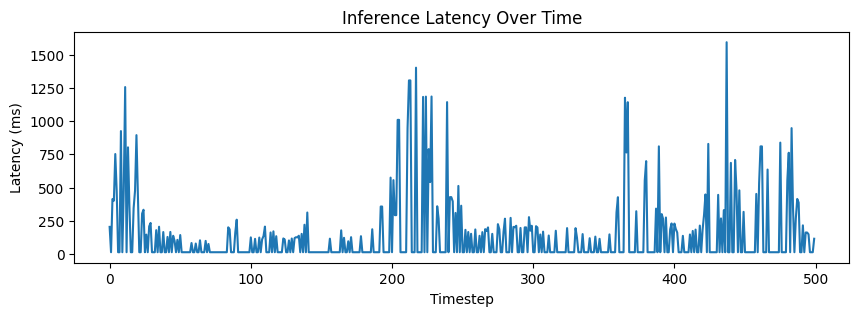

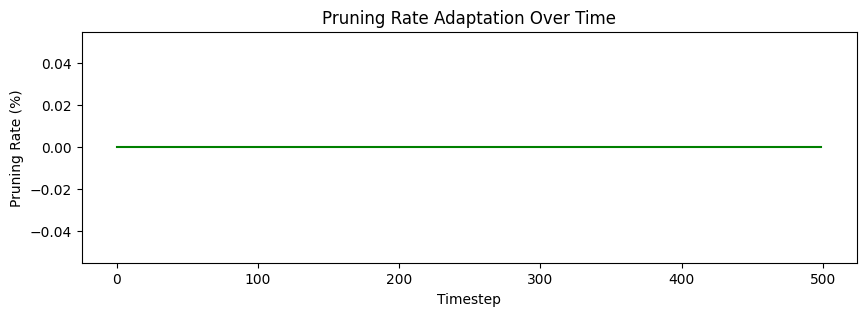

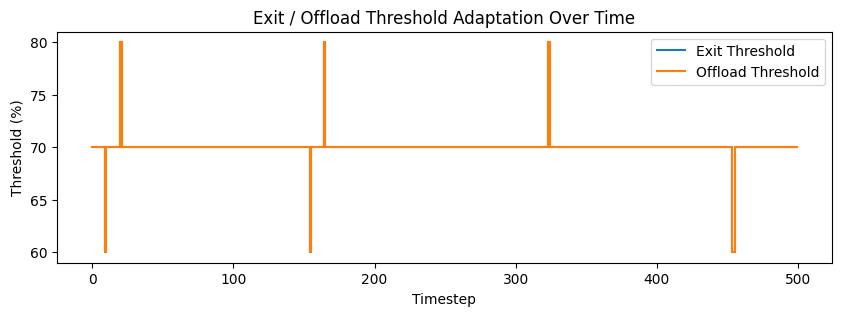

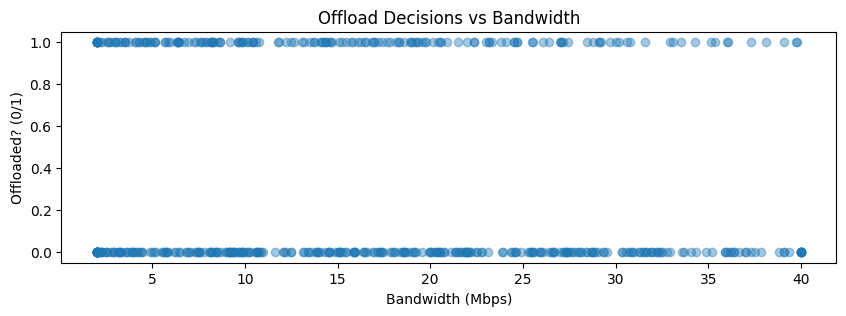

In [ ]:
# --- Metrics summary (like Table III in the base paper) ---
summary = {
    "Avg Latency (ms)": df["latency_ms"].mean(),
    "Accuracy (%)": 100 * df["correct"].mean(),
    "Inference Loss (%)": 100 * (1 - df["correct"].mean()),
    "Offload Rate (%)": 100 * df["offload"].mean(),
    "Avg Pruning Rate (%)": df["pruning_rate"].mean(),
}
print(pd.Series(summary))

# --- Plot 1: Latency over time ---
plt.figure(figsize=(10, 3))
plt.plot(df["timestep"], df["latency_ms"])
plt.xlabel("Timestep"); plt.ylabel("Latency (ms)")
plt.title("Inference Latency Over Time")
plt.show()

# --- Plot 2: Pruning rate adaptation over time (like Fig. 11) ---
plt.figure(figsize=(10, 3))
plt.plot(df["timestep"], df["pruning_rate"], drawstyle="steps-post", color="green")
plt.xlabel("Timestep"); plt.ylabel("Pruning Rate (%)")
plt.title("Pruning Rate Adaptation Over Time")
plt.show()

# --- Plot 3: Exit / Offload threshold adaptation over time ---
plt.figure(figsize=(10, 3))
plt.plot(df["timestep"], df["exit_threshold"], label="Exit Threshold", drawstyle="steps-post")
plt.plot(df["timestep"], df["offload_threshold"], label="Offload Threshold", drawstyle="steps-post")
plt.xlabel("Timestep"); plt.ylabel("Threshold (%)")
plt.title("Exit / Offload Threshold Adaptation Over Time")
plt.legend()
plt.show()

# --- Plot 4: Bandwidth vs offload decision ---
plt.figure(figsize=(10, 3))
plt.scatter(df["bandwidth"], df["offload"].astype(int), alpha=0.4)
plt.xlabel("Bandwidth (Mbps)"); plt.ylabel("Offloaded? (0/1)")
plt.title("Offload Decisions vs Bandwidth")
plt.show()